# ATLAS Hydro present river discharge maps

This notebook creates present day river discharge maps from GLOFAS basin statistics and can optionally integrate in situ hydrological station observations.

It combines the two previous workflows into one reusable notebook:

1. If station observations are available, the notebook integrates them with the HydroBASINS level 12 GLOFAS statistics.
2. If station observations are not available, the notebook skips the integration step and uses the original GLOFAS basin statistics directly.

The workflow is organised step by step for users who are not expert Python users. Most user specific settings are collected in the configuration cell below.

Expected inputs:

1. HydroBASINS shapefiles for the correct continent.
2. HydroRIVERS shapefile for the correct continent.
3. Country boundary shapefile.
4. Basin statistics generated by the previous notebook.
5. Optional station observations in CSV format.

### HydroBASINS data

HydroBASINS catchment boundaries can be downloaded from the HydroSHEDS portal: https://www.hydrosheds.org/products/hydrobasins. For countries in South America, download the **South America (sa)** dataset and extract the archive into the project data directory.

The workflow uses HydroBASINS levels 5 and 12 (`hybas_lake_sa_lev05_v1c.shp` and `hybas_lake_sa_lev12_v1c.shp`) to aggregate river discharge values and compute basin scale statistics.

### HydroRIVERS data

River network data can be downloaded from the HydroSHEDS portal: https://www.hydrosheds.org/products/hydrorivers. For countries in South America, download the **South America (sa)** HydroRIVERS dataset and extract the archive into the project data directory.

The workflow uses the HydroRIVERS shapefile (`HydroRIVERS_v10_sa.shp`) to display the river network and provide geographic context in the river discharge maps. Only the main river reaches are typically displayed in the final visualisations.

## Step 1. Import Python libraries

Run this cell first. If an import fails, install the missing package in your Python environment before continuing.

In [1]:
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs

warnings.filterwarnings("ignore")

ERROR 1: PROJ: proj_create_from_database: Open of /home/alessandrom/anaconda3/envs/bias_correction_conda/share/proj failed


## Step 2. Set project parameters and paths

Only this cell should normally be edited when changing country, folder structure, or whether station observations should be used.

`COUNTRY_FOLDER` is the lowercase folder name used in the data directories.

`COUNTRY_NAME_IN_SHAPEFILE` must match the country name in the `ADMIN` column of the Natural Earth shapefile.

Set `USE_STATIONS = True` when station observations are available. Set `USE_STATIONS = False` for countries without station data, such as the Bolivia case.

In [2]:
# Country settings
COUNTRY_FOLDER = "ecuador"      # Examples: "ecuador", "bolivia"
COUNTRY_NAME_IN_SHAPEFILE = "Ecuador"  # Examples: "Ecuador", "Bolivia"

# Set this to True only when a station CSV is available for the selected country.
USE_STATIONS = True

# Weight assigned to station observations when USE_STATIONS = True.
# Example: 0.4 means 40% station observation and 60% GLOFAS basin statistic.
STATION_WEIGHT = 0.4

# Input folders
PROCESSED_GLOFAS_FOLDER = Path(f"../data/processed/river_discharge/{COUNTRY_FOLDER}")
BASIN_STATISTICS_FOLDER = Path(f"../data/basin_statistics/{COUNTRY_FOLDER}")
STATIONS_FOLDER = Path(f"../data/stations/{COUNTRY_FOLDER}")

# Static geographical layers
COUNTRY_SHAPEFILE = Path("../world_map/ne_50m_admin_0_countries.shp")
HYDROBASINS_FOLDER = Path("../hydrobasins")
HYDRORIVERS_FILE = Path("../hydrorivers/HydroRIVERS_v10_sa_shp/HydroRIVERS_v10_sa.shp")

# Output folders
OUTPUT_FOLDER = Path(f"../data/atlas_data/{COUNTRY_FOLDER}")
FIGURES_FOLDER = Path(f"../data/figures/{COUNTRY_FOLDER}")

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
FIGURES_FOLDER.mkdir(parents=True, exist_ok=True)

print("Country folder:", COUNTRY_FOLDER)
print("Country name in shapefile:", COUNTRY_NAME_IN_SHAPEFILE)
print("Use stations:", USE_STATIONS)
print("Basin statistics folder:", BASIN_STATISTICS_FOLDER)
print("Stations folder:", STATIONS_FOLDER)
print("Output folder:", OUTPUT_FOLDER)
print("Figures folder:", FIGURES_FOLDER)

Country folder: ecuador
Country name in shapefile: Ecuador
Use stations: True
Basin statistics folder: ../data/basin_statistics/ecuador
Stations folder: ../data/stations/ecuador
Output folder: ../data/atlas_data/ecuador
Figures folder: ../data/figures/ecuador


## Step 3. Choose the month or annual aggregation

Set `ANNUAL_PLOT = False` to work on one month.

Set `ANNUAL_PLOT = True` to average the twelve monthly files and create an annual map.

In [3]:
MONTH = 1
ANNUAL_PLOT = False

MONTH_NAMES = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

if ANNUAL_PLOT:
    PERIOD_LABEL = "Annual"
    PERIOD_SUFFIX = "annual"
else:
    PERIOD_LABEL = MONTH_NAMES[MONTH - 1]
    PERIOD_SUFFIX = f"m{MONTH}"

METHOD_SUFFIX = "integrated" if USE_STATIONS else "glofas"

L12_FIGURE_FILE = FIGURES_FOLDER / f"river_discharge_{COUNTRY_FOLDER}_{PERIOD_SUFFIX}_level12_{METHOD_SUFFIX}.png"
L5_FIGURE_FILE = FIGURES_FOLDER / f"river_discharge_{COUNTRY_FOLDER}_{PERIOD_SUFFIX}_level5_{METHOD_SUFFIX}.png"

print("Selected period:", PERIOD_LABEL)
print("Method suffix:", METHOD_SUFFIX)
print("Level 12 figure:", L12_FIGURE_FILE)
print("Level 5 figure:", L5_FIGURE_FILE)

Selected period: January
Method suffix: integrated
Level 12 figure: ../data/figures/ecuador/river_discharge_ecuador_m1_level12_integrated.png
Level 5 figure: ../data/figures/ecuador/river_discharge_ecuador_m1_level5_integrated.png


## Step 4. Load the country boundary

The country boundary is used to clip HydroBASINS and HydroRIVERS to the study area.

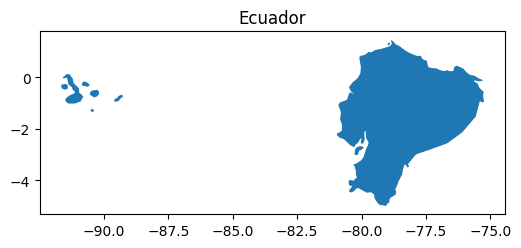

In [4]:
countries = gpd.read_file(COUNTRY_SHAPEFILE)[["ADMIN", "geometry"]].set_index("ADMIN")
country_boundary = countries.loc[[COUNTRY_NAME_IN_SHAPEFILE]]
country_geometry = country_boundary.geometry.iloc[0]

country_boundary.plot(figsize=(6, 6))
plt.title(COUNTRY_NAME_IN_SHAPEFILE)
plt.show()

## Step 5. Load rivers and HydroBASINS features

HydroBASINS level 12 is used for the detailed map and optional station integration.

HydroBASINS level 5 is used for the final aggregated map.

In [ ]:
def load_hydrobasins_for_country(level, country_geometry):
    level_string = str(level).zfill(2)
    basin_file = HYDROBASINS_FOLDER / f"hybas_lake_sa_lev{level_string}_v1c.shp"
    basins = gpd.read_file(basin_file)

    lakes = basins[basins["LAKE"] == 1].copy()
    basins = basins[basins["LAKE"] == 0].copy()

    country_basins = gpd.clip(basins, country_geometry)
    country_lakes = gpd.clip(lakes, country_geometry)

    return country_basins, country_lakes

rivers = gpd.read_file(HYDRORIVERS_FILE)
country_rivers = gpd.clip(rivers, country_geometry)

# Keep the main river network only. Higher ORD_FLOW values represent smaller river reaches.
country_rivers = country_rivers[country_rivers["ORD_FLOW"] < 7].copy()

country_basins_l12, country_lakes_l12 = load_hydrobasins_for_country(12, country_geometry)
country_basins_l5, country_lakes_l5 = load_hydrobasins_for_country(5, country_geometry)

country_basins_l12["L5basin"] = country_basins_l12["PFAF_ID"].astype(str).str[:5].astype(int)

print("Level 12 basins:", len(country_basins_l12))
print("Level 5 basins:", len(country_basins_l5))
print("Rivers:", len(country_rivers))

## Step 6. Load basin statistics from the previous notebook

The previous notebook should have produced one CSV per month at level 12, named like:

`river_discharge_l12_ecuador_m1.csv`

If `ANNUAL_PLOT = True`, this notebook loads all twelve monthly CSV files and computes their average.

In [ ]:
def read_l12_basin_statistics_for_month(month):
    input_file = BASIN_STATISTICS_FOLDER / f"river_discharge_l12_{COUNTRY_FOLDER}_m{month}.csv"
    df = pd.read_csv(input_file)

    if "Unnamed: 0" in df.columns:
        df = df.drop(columns="Unnamed: 0")

    if "geometry" not in df.columns:
        raise ValueError(
            f"The file {input_file} does not contain a 'geometry' column. "
            "Please rerun the basin statistics notebook with geometry saved as WKT."
        )

    df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

    return gdf

if ANNUAL_PLOT:
    monthly_files = []

    for month in range(1, 13):
        monthly_gdf = read_l12_basin_statistics_for_month(month)
        monthly_gdf = monthly_gdf.rename(
            columns={"mean_river_discharge": f"river_discharge_m{month}"}
        )
        monthly_files.append(monthly_gdf)

    gdf_l12 = monthly_files[0].copy().drop(columns="river_discharge_m1")
    monthly_columns = [monthly_files[i][f"river_discharge_m{i + 1}"] for i in range(12)]
    gdf_l12["mean_river_discharge"] = pd.concat(monthly_columns, axis=1).mean(axis=1)
else:
    gdf_l12 = read_l12_basin_statistics_for_month(MONTH)

gdf_l12["mean_river_discharge"] = gdf_l12["mean_river_discharge"].fillna(1)

print(gdf_l12.head())
print("Number of level 12 basins with data:", len(gdf_l12))

## Step 7. Optionally load station observations

This step is active only when `USE_STATIONS = True`.

The station CSV is expected to contain at least these columns:

`id`, `month`, `latitude`, `longitude`, `river_discharge`

For monthly maps, only the selected month is used. For annual maps, station values are averaged by station id.

If `USE_STATIONS = False`, the notebook creates an empty station layer and continues with the original GLOFAS basin statistics.

In [ ]:
STATIONS_FILE = STATIONS_FOLDER / f"allstats_river_discharge_{COUNTRY_FOLDER}.csv"

if USE_STATIONS:
    stations_data = pd.read_csv(STATIONS_FILE)

    if ANNUAL_PLOT:
        stations_selected = (
            stations_data
            .groupby("id", as_index=False)
            .mean(numeric_only=True)
        )
    else:
        stations_selected = stations_data[stations_data["month"] == MONTH].copy()

    stations_gdf = gpd.GeoDataFrame(
        stations_selected,
        geometry=gpd.points_from_xy(stations_selected["longitude"], stations_selected["latitude"]),
        crs="EPSG:4326"
    )
    stations_gdf = stations_gdf.to_crs(gdf_l12.crs)

    print("Stations used:", len(stations_gdf))
else:
    stations_gdf = gpd.GeoDataFrame(columns=["id", "river_discharge", "geometry"], geometry="geometry", crs=gdf_l12.crs)
    print("USE_STATIONS is False. Station integration will be skipped.")

stations_gdf.head()

## Step 8. Create the final level 12 dataset

If station observations are available, each HydroBASINS level 12 polygon that contains one or more stations is corrected using a weighted average between the station observation and the original basin statistic.

The formula is:

$$Q_{integrated} = w \cdot Q_{station} + (1 - w) \cdot Q_{basin}$$

If station observations are not available, the notebook simply copies `mean_river_discharge` into a common output column named `mean_river_discharge_final`. This makes the rest of the workflow identical for both cases.

In [8]:
def integrate_station_observations(stations_gdf, basins_gdf, station_weight):
    joined = gpd.sjoin(
        stations_gdf,
        basins_gdf[["HYBAS_ID", "mean_river_discharge", "geometry"]],
        how="left",
        predicate="within"
    )

    station_values = (
        joined
        .groupby("HYBAS_ID")["river_discharge"]
        .mean()
        .reset_index()
    )

    integrated = basins_gdf.merge(station_values, on="HYBAS_ID", how="left")
    integrated["mean_river_discharge_final"] = integrated["mean_river_discharge"]

    mask = integrated["river_discharge"].notna()

    integrated.loc[mask, "mean_river_discharge_final"] = (
        station_weight * integrated.loc[mask, "river_discharge"]
        + (1 - station_weight) * integrated.loc[mask, "mean_river_discharge"]
    )

    return integrated

if USE_STATIONS:
    gdf_l12_final = integrate_station_observations(
        stations_gdf=stations_gdf,
        basins_gdf=gdf_l12,
        station_weight=STATION_WEIGHT
    )
    print("Basins corrected with stations:", gdf_l12_final["river_discharge"].notna().sum())
else:
    gdf_l12_final = gdf_l12.copy()
    gdf_l12_final["river_discharge"] = np.nan
    gdf_l12_final["mean_river_discharge_final"] = gdf_l12_final["mean_river_discharge"]
    print("No station correction applied.")

gdf_l12_final["mean_river_discharge_final"] = gdf_l12_final["mean_river_discharge_final"].fillna(1)
gdf_l12_final.head()

Basins corrected with stations: 24


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,SIDE,LAKE,ENDO,COAST,ORDER,SORT,geometry,mean_river_discharge,river_discharge,mean_river_discharge_final
0,6120032930,0,6120032930,6120032930,0.0,0.0,217.8,217.8,672030393010,M,0,0,1,0,138120,"POLYGON ((-80.82874 -1.23226, -80.85033 -1.209...",1.199093,NaN,1.199093
1,6121051620,6120230300,6120007000,6120007000,4694.3,4694.3,129.2,129.2,622986860200,M,0,0,0,5,65188,"POLYGON ((-78.81891 -1.11197, -78.82707 -1.104...",2.523690,NaN,2.523690
2,6120230480,6121052540,6120007000,6120007000,4673.4,4673.4,12.0,2018.8,622986850000,M,0,0,0,4,65076,"POLYGON ((-78.60896 -1.06341, -78.61250 -1.062...",53.523438,7.437395,35.089020
3,6121052302,6121052301,6120032970,6120032970,85.4,85.4,56.6,173.4,672030409200,R,0,0,0,1,138140,"POLYGON ((-80.15221 -1.10057, -80.15280 -1.101...",1.000000,NaN,1.000000
4,6120230211,6129504941,6120007000,6120007000,4278.6,4278.6,54.1,3221.2,622978973000,L,0,0,0,2,62407,"POLYGON ((-77.81158 -1.06725, -77.81307 -1.073...",212.947388,NaN,212.947388


## Step 9. Aggregate level 12 values to HydroBASINS level 5

The aggregation uses the level 12 basin area as weight. This produces one river discharge value for each level 5 basin using the same method whether station integration is active or not.

In [9]:
def aggregate_to_lower_basin_level(high_resolution_gdf, low_resolution_basins, value_column):
    high_resolution_gdf = high_resolution_gdf.to_crs(low_resolution_basins.crs)

    high_resolution_points = high_resolution_gdf.copy()
    high_resolution_points["geometry"] = high_resolution_points.geometry.representative_point()

    joined = gpd.sjoin(
        high_resolution_points,
        low_resolution_basins[["HYBAS_ID", "geometry"]],
        how="left",
        predicate="within"
    )

    joined["weighted_discharge"] = joined[value_column] * joined["SUB_AREA"]

    aggregated = (
        joined
        .groupby("HYBAS_ID_right")
        .agg(
            weighted_discharge=("weighted_discharge", "sum"),
            area=("SUB_AREA", "sum")
        )
        .reset_index()
    )

    aggregated[value_column] = aggregated["weighted_discharge"] / aggregated["area"]
    aggregated = aggregated.rename(columns={"HYBAS_ID_right": "HYBAS_ID"})

    output_gdf = low_resolution_basins.merge(
        aggregated[["HYBAS_ID", value_column]],
        on="HYBAS_ID",
        how="left"
    )

    return output_gdf

VALUE_COLUMN = "mean_river_discharge_final"
gdf_l5_final = aggregate_to_lower_basin_level(gdf_l12_final, country_basins_l5, VALUE_COLUMN)
gdf_l5_final[VALUE_COLUMN] = gdf_l5_final[VALUE_COLUMN].fillna(1)

print("Level 5 basins:", len(gdf_l5_final))
gdf_l5_final.head()

Level 5 basins: 11


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,SIDE,LAKE,ENDO,COAST,ORDER,SORT,geometry,mean_river_discharge_final
0,6050315910,6050266740,6050007000,6050007000,3493.7,3493.7,364869.2,364873.4,62298,M,0,0,0,2,178,"POLYGON ((-79.39640 -4.83971, -79.39583 -4.837...",49.281872
1,6050032100,0,6050032100,6050032100,0.0,0.0,17761.9,17761.9,67108,M,0,0,0,1,516,"MULTIPOLYGON (((-79.33715 -4.54826, -79.33369 ...",25.349405
2,6050032110,0,6050032110,6050032110,0.0,0.0,11236.5,11236.5,67109,M,0,0,1,0,517,"POLYGON ((-79.45085 -3.55502, -79.45000 -3.558...",54.172108
3,6050032290,0,6050032290,6050032290,0.0,0.0,16478.7,16478.7,67201,M,0,0,1,0,518,"MULTIPOLYGON (((-79.80355 -2.38433, -79.80594 ...",29.480832
4,6050266740,6050287820,6050007000,6050007000,2156.8,2156.8,514725.6,1233304.8,62297,M,0,0,0,1,165,"POLYGON ((-75.83245 -1.82012, -75.83390 -1.814...",132.360442


## Step 10. Define a reusable plotting function

This function creates a map of river discharge for the selected basin layer.

For Ecuador, the function includes an optional inset for Galápagos. For most other countries, keep `ADD_GALAPAGOS_INSET = False`.

In [18]:
ADD_GALAPAGOS_INSET = COUNTRY_FOLDER.lower() == "ecuador"

# Longitude threshold used only for Ecuador.
# Galápagos are located around 90°W, while continental Ecuador is around 75-82°W.
# The main map therefore shows only continental Ecuador, and Galápagos are shown only in the inset.
ECUADOR_MAINLAND_MIN_LONGITUDE = -82.5
GALAPAGOS_EXTENT = [-92.2, -89.0, -1.7, 0.8]


def keep_mainland_ecuador(gdf):
    """Return only geometries located in continental Ecuador.

    This function is used only when the Galápagos inset is active.
    It removes geometries whose centroid falls west of the longitude threshold.
    """
    if gdf is None or len(gdf) == 0:
        return gdf

    centroids = gdf.geometry.centroid
    return gdf[centroids.x > ECUADOR_MAINLAND_MIN_LONGITUDE].copy()


def keep_galapagos(gdf):
    """Return only geometries located in the Galápagos area."""
    if gdf is None or len(gdf) == 0:
        return gdf

    minx, maxx = GALAPAGOS_EXTENT[0], GALAPAGOS_EXTENT[1]
    miny, maxy = GALAPAGOS_EXTENT[2], GALAPAGOS_EXTENT[3]

    centroids = gdf.geometry.centroid
    mask = (
        (centroids.x >= minx) &
        (centroids.x <= maxx) &
        (centroids.y >= miny) &
        (centroids.y <= maxy)
    )
    return gdf[mask].copy()


def get_main_map_boundary():
    """Return the boundary used to define the main map extent.

    For Ecuador, this is the continental part only. For other countries, it is the
    full country boundary.
    """
    if not ADD_GALAPAGOS_INSET:
        return country_boundary

    exploded = country_boundary.explode(index_parts=False).reset_index(drop=True)
    centroids = exploded.geometry.centroid
    mainland = exploded[centroids.x > ECUADOR_MAINLAND_MIN_LONGITUDE].copy()

    if len(mainland) == 0:
        return country_boundary

    return mainland


def plot_river_discharge_map(
    basins_gdf,
    value_column,
    rivers_gdf,
    lakes_gdf,
    ticks,
    norm,
    title,
    output_file,
    add_galapagos_inset=False
):
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(12, 10),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    # For Ecuador, the main panel shows only continental Ecuador.
    # The Galápagos geometries are plotted separately in the inset.
    if add_galapagos_inset:
        main_basins_gdf = keep_mainland_ecuador(basins_gdf)
        main_rivers_gdf = keep_mainland_ecuador(rivers_gdf)
        main_lakes_gdf = keep_mainland_ecuador(lakes_gdf)
        main_boundary = get_main_map_boundary()

        inset_basins_gdf = keep_galapagos(basins_gdf)
        inset_rivers_gdf = keep_galapagos(rivers_gdf)
        inset_lakes_gdf = keep_galapagos(lakes_gdf)
    else:
        main_basins_gdf = basins_gdf
        main_rivers_gdf = rivers_gdf
        main_lakes_gdf = lakes_gdf
        main_boundary = country_boundary

        inset_basins_gdf = basins_gdf
        inset_rivers_gdf = rivers_gdf
        inset_lakes_gdf = lakes_gdf

    main_basins_gdf.plot(
        column=value_column,
        ax=ax,
        cmap="Blues",
        legend=False,
        norm=norm,
        edgecolor="k",
        linewidth=0.5
    )

    main_rivers = main_rivers_gdf[main_rivers_gdf["ORD_FLOW"] < 6]
    if len(main_rivers) > 0:
        main_rivers.plot(
            ax=ax,
            color="orange",
            linewidth=3 / main_rivers["ORD_FLOW"]
        )

    if len(main_lakes_gdf) > 0:
        main_lakes_gdf.plot(ax=ax, facecolor="green", edgecolor="none", zorder=10)

    ax.coastlines(linewidth=0.5)

    minx, miny, maxx, maxy = main_boundary.total_bounds
    padding_x = (maxx - minx) * 0.05
    padding_y = (maxy - miny) * 0.05
    ax.set_extent(
        [minx - padding_x, maxx + padding_x, miny - padding_y, maxy + padding_y],
        crs=ccrs.PlateCarree()
    )

    ax.set_title(title, fontsize=22)

    gridlines = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="black",
        alpha=0.5,
        linestyle="--"
    )
    gridlines.top_labels = False
    gridlines.right_labels = False
    gridlines.xformatter = LONGITUDE_FORMATTER
    gridlines.yformatter = LATITUDE_FORMATTER
    gridlines.xlabel_style = {"size": 14}
    gridlines.ylabel_style = {"size": 14}

    if add_galapagos_inset:
        main_pos = ax.get_position()

        # Position of the inset inside the figure.
        # Values can be adjusted manually if needed.
        inset_left = main_pos.x0 + main_pos.width * 0.5
        inset_bottom = main_pos.y0 + main_pos.height * 0.1
        inset_width = main_pos.width * 0.26
        inset_height = main_pos.height * 0.24

        inset_ax = fig.add_axes(
            [inset_left, inset_bottom, inset_width, inset_height],
            projection=ccrs.PlateCarree()
        )

        if len(inset_basins_gdf) > 0:
            inset_basins_gdf.plot(
                column=value_column,
                ax=inset_ax,
                cmap="Blues",
                legend=False,
                norm=norm,
                edgecolor="k",
                linewidth=0.5
            )

        inset_rivers = inset_rivers_gdf[inset_rivers_gdf["ORD_FLOW"] < 7]
        if len(inset_rivers) > 0:
            inset_rivers.plot(
                ax=inset_ax,
                color="orange",
                linewidth=3 / inset_rivers["ORD_FLOW"]
            )

        if len(inset_lakes_gdf) > 0:
            inset_lakes_gdf.plot(ax=inset_ax, facecolor="green", edgecolor="none", zorder=10)

        inset_ax.coastlines(linewidth=0.4)
        inset_ax.set_extent(GALAPAGOS_EXTENT, crs=ccrs.PlateCarree())
        inset_ax.set_title("Galápagos", fontsize=14)

        inset_ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=False,
            linewidth=0.3,
            color="black",
            alpha=0.4,
            linestyle="--"
        )

    colorbar_object = plt.cm.ScalarMappable(norm=norm, cmap="Blues")
    colorbar_object.set_array(np.array([1]))
    colorbar = fig.colorbar(colorbar_object, ax=ax, orientation="vertical", aspect=25, shrink=0.75)
    colorbar.set_ticks(ticks)
    colorbar.set_ticklabels(ticks)
    colorbar.set_label("m³/s", size=16)
    colorbar.ax.tick_params(labelsize=14)

    plt.savefig(output_file, dpi=150, bbox_inches="tight")
    plt.show()

    return fig


## Step 11. Plot and save the level 12 map

The level 12 map shows the most detailed basin representation. If stations are used, this map shows the station integrated values. Otherwise, it shows the original GLOFAS basin statistics.

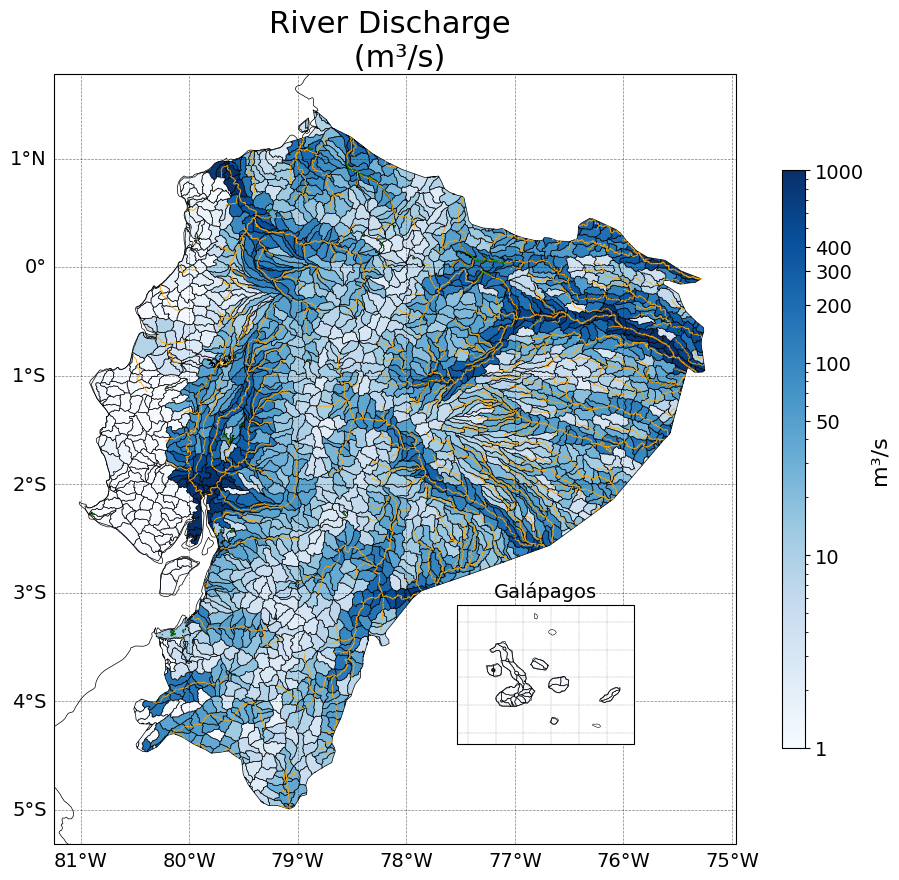

In [19]:
l12_norm = colors.LogNorm(vmin=1, vmax=1000)
l12_ticks = [1, 10, 50, 100, 200, 300, 400, 1000]

fig = plot_river_discharge_map(
    basins_gdf=gdf_l12_final,
    value_column=VALUE_COLUMN,
    rivers_gdf=country_rivers,
    lakes_gdf=country_lakes_l12,
    ticks=l12_ticks,
    norm=l12_norm,
    title="River Discharge \n (m³/s)",
    output_file=L12_FIGURE_FILE,
    add_galapagos_inset=ADD_GALAPAGOS_INSET
)

## Step 12. Plot and save the level 5 map

The level 5 map shows the aggregated river discharge values and is useful for regional scale visualisation.

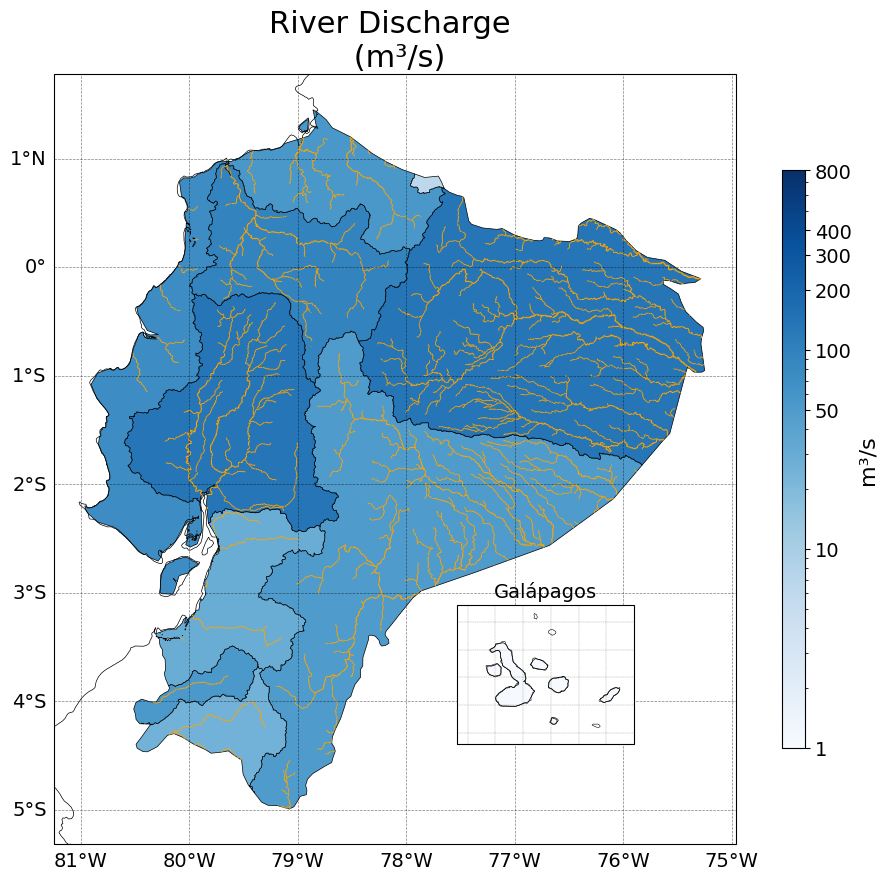

In [20]:
l5_norm = colors.LogNorm(vmin=1, vmax=800)
l5_ticks = [1, 10, 50, 100, 200, 300, 400, 800]

fig = plot_river_discharge_map(
    basins_gdf=gdf_l5_final,
    value_column=VALUE_COLUMN,
    rivers_gdf=country_rivers,
    lakes_gdf=country_lakes_l5,
    ticks=l5_ticks,
    norm=l5_norm,
    title="River Discharge \n (m³/s)",
    output_file=L5_FIGURE_FILE,
    add_galapagos_inset=ADD_GALAPAGOS_INSET
)

## Step 13. Save the level 12 and level 5 datasets

The level 12 output is saved as CSV. The level 5 output is saved as GeoJSON and can be opened directly in GIS software.

The common output column is `mean_river_discharge_final`.

If `USE_STATIONS = True`, this column contains station integrated values.

If `USE_STATIONS = False`, this column contains the original GLOFAS basin statistics.

In [21]:
if ANNUAL_PLOT:
    l12_output_file = OUTPUT_FOLDER / f"river_discharge_l12_{COUNTRY_FOLDER}_annual_{METHOD_SUFFIX}.csv"
    l5_output_file = OUTPUT_FOLDER / f"river_discharge_l5_{COUNTRY_FOLDER}_annual_{METHOD_SUFFIX}.geojson"
else:
    l12_output_file = OUTPUT_FOLDER / f"river_discharge_l12_{COUNTRY_FOLDER}_m{MONTH}_{METHOD_SUFFIX}.csv"
    l5_output_file = OUTPUT_FOLDER / f"river_discharge_l5_{COUNTRY_FOLDER}_m{MONTH}_{METHOD_SUFFIX}.geojson"

columns_to_drop = [column for column in ["river_discharge"] if column in gdf_l12_final.columns]
gdf_l12_output = gdf_l12_final.drop(columns=columns_to_drop)

gdf_l12_output.to_csv(l12_output_file, index=False)
gdf_l5_final.to_file(l5_output_file, driver="GeoJSON")

print("Saved level 12 dataset:", l12_output_file)
print("Saved level 5 dataset:", l5_output_file)

Saved level 12 dataset: ../data/atlas_data/ecuador/river_discharge_l12_ecuador_m1_integrated.csv
Saved level 5 dataset: ../data/atlas_data/ecuador/river_discharge_l5_ecuador_m1_integrated.geojson


## Step 14. Optional quality check: inspect one level 5 basin

This section plots the level 12 subbasins inside one selected level 5 basin. It is useful for checking whether the integration and aggregation look spatially consistent.

In [22]:
SELECTED_L5_BASIN_INDEX = 1

selected_l5_basin = gpd.GeoDataFrame(country_basins_l5.iloc[[SELECTED_L5_BASIN_INDEX]])
selected_l5_pfaf = selected_l5_basin["PFAF_ID"].iloc[0]

selected_l12_basins = country_basins_l12[country_basins_l12["L5basin"] == selected_l5_pfaf]
selected_rivers = gpd.clip(country_rivers, selected_l5_basin)

gdf_l12_final["L5basin"] = gdf_l12_final["PFAF_ID"].astype(str).str[:5].astype(int)
selected_l12_final = gdf_l12_final[gdf_l12_final["L5basin"] == selected_l5_pfaf].copy()
selected_l12_final[VALUE_COLUMN] = selected_l12_final[VALUE_COLUMN].fillna(1)

print("Selected level 5 PFAF ID:", selected_l5_pfaf)
print("Level 12 subbasins inside selected basin:", len(selected_l12_final))

Selected level 5 PFAF ID: 67108
Level 12 subbasins inside selected basin: 68


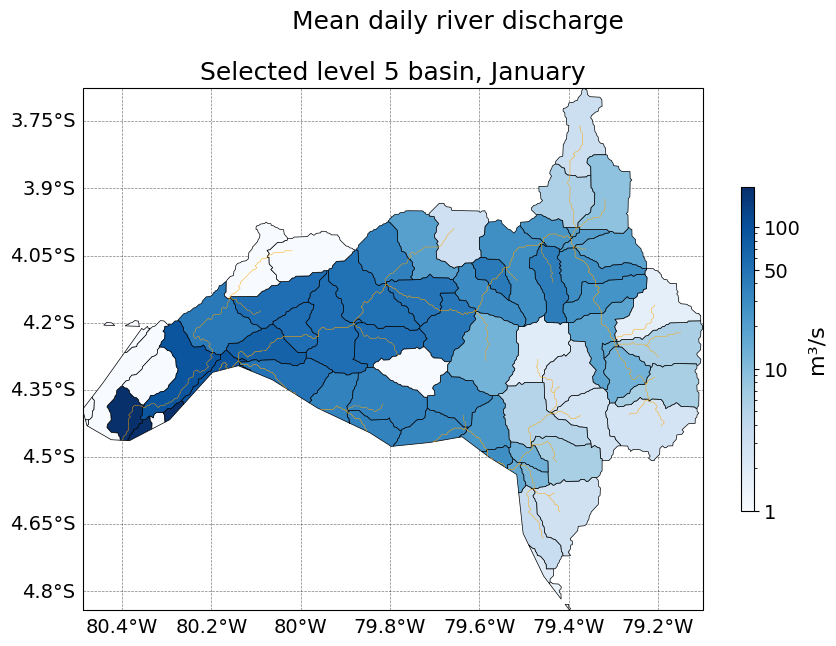

In [23]:
basin_bounds = selected_l5_basin.total_bounds
maximum_value = max(selected_l12_final[VALUE_COLUMN].max(), 1)

single_basin_norm = colors.LogNorm(vmin=1, vmax=maximum_value)
single_basin_ticks = [tick for tick in [1, 10, 50, 100, 200, 300, 400, 800, 1500] if tick <= maximum_value]
if len(single_basin_ticks) == 0:
    single_basin_ticks = [1]

fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent(
    [basin_bounds[0], basin_bounds[2], basin_bounds[1], basin_bounds[3]],
    crs=ccrs.PlateCarree()
)

ax.coastlines(linewidth=0.5)

gridlines = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="black",
    alpha=0.5,
    linestyle="--"
)
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER
gridlines.xlabel_style = {"size": 14}
gridlines.ylabel_style = {"size": 14}

if len(selected_rivers) > 0:
    selected_rivers.plot(
        ax=ax,
        color="orange",
        linewidth=2 / selected_rivers["ORD_FLOW"],
        zorder=3
    )

if len(country_lakes_l5) > 0:
    country_lakes_l5.plot(
        ax=ax,
        facecolor="grey",
        edgecolor="none",
        zorder=4
    )

selected_l12_final.plot(
    column=VALUE_COLUMN,
    ax=ax,
    cmap="Blues",
    legend=False,
    norm=single_basin_norm,
    edgecolor="k",
    linewidth=0.5,
    zorder=2
)

ax.set_title(f"Selected level 5 basin, {PERIOD_LABEL}", fontsize=18)
plt.suptitle("Mean daily river discharge", fontsize=18)

colorbar_object = plt.cm.ScalarMappable(norm=single_basin_norm, cmap="Blues")
colorbar_object.set_array(np.array([1]))
colorbar = fig.colorbar(colorbar_object, ax=ax, orientation="vertical", shrink=0.6, aspect=25)
colorbar.set_ticks(single_basin_ticks)
colorbar.set_ticklabels(single_basin_ticks)
colorbar.set_label("m³/s", size=16)
colorbar.ax.tick_params(labelsize=14)

plt.show()

## Notes for reuse

To run the notebook for another country, update Step 2 and make sure the HydroBASINS and HydroRIVERS files refer to the correct continent.

Use `USE_STATIONS = True` for countries with station data and `USE_STATIONS = False` for countries without station data.

The main outputs are:

1. Level 12 CSV.
2. Level 5 GeoJSON.
3. Level 12 PNG map.
4. Level 5 PNG map.